In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
loan=pd.read_csv(r"C:\Users\Yatish Agarwal\Downloads\credit_risk_dataset (1).csv")
print(loan)

     Age    Income  Loan_Amount  Credit_Score  Employment_Years  \
0     59   52154.0        11276           823                15   
1     49  116646.0        43663           315                 5   
2     35   61157.0        18994           428                 8   
3     63   52154.0        28499           408                26   
4     28  148876.0        28040           832                 3   
..   ...       ...          ...           ...               ...   
995   53   44519.0         7307           433                22   
996   22  107487.0        44901           582                 7   
997   34  102870.0        16205           372                29   
998   60   66197.0        10906           780                24   
999   60       NaN         7591           651                 5   

    Education_Level Housing_Status  Default  
0         Bachelors            Own        0  
1               PhD            Own        0  
2           Masters            Own        1  
3         B

In [10]:
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1000 non-null   int64  
 1   Income            985 non-null    float64
 2   Loan_Amount       1000 non-null   int64  
 3   Credit_Score      1000 non-null   int64  
 4   Employment_Years  1000 non-null   int64  
 5   Education_Level   1000 non-null   str    
 6   Housing_Status    1000 non-null   str    
 7   Default           1000 non-null   int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 62.6 KB


In [11]:
loan.isnull().sum()

Age                  0
Income              15
Loan_Amount          0
Credit_Score         0
Employment_Years     0
Education_Level      0
Housing_Status       0
Default              0
dtype: int64

In [12]:
loan['Income'] = loan['Income'].fillna(loan['Income'].median())
loan.isnull().sum()

Age                 0
Income              0
Loan_Amount         0
Credit_Score        0
Employment_Years    0
Education_Level     0
Housing_Status      0
Default             0
dtype: int64

In [13]:
print(f"Duplicate rows found: {loan.duplicated().sum()}")
loan = loan.drop_duplicates().reset_index(drop=True)

Duplicate rows found: 0


In [14]:
loan.describe()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Default
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,42.515000,82210.922000,27729.324000,581.05000,15.164000,0.138000
std,12.611059,36566.421577,12774.836247,158.59334,8.593075,0.345073
min,21.000000,20922.000000,5097.000000,300.00000,0.000000,0.000000
25%,32.000000,52154.000000,16387.500000,441.00000,8.000000,0.000000
50%,43.000000,79379.000000,28483.500000,582.00000,15.000000,0.000000
75%,53.000000,116646.000000,38535.500000,720.25000,23.000000,0.000000
max,64.000000,149038.000000,49976.000000,849.00000,29.000000,1.000000


In [15]:
print("Unique Education Levels:")
print(loan['Education_Level'].unique())

print("\nUnique Housing Statuses:")
print(loan['Housing_Status'].unique())

Unique Education Levels:
<StringArray>
['Bachelors', 'PhD', 'Masters', 'High School']
Length: 4, dtype: str

Unique Housing Statuses:
<StringArray>
['Own', 'Rent', 'Mortgage']
Length: 3, dtype: str


In [16]:
# Run this to convert categorical variables into dummy numerical columns
loan_encoded = pd.get_dummies(loan, columns=['Education_Level', 'Housing_Status'], drop_first=True)
loan_encoded.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Default,Education_Level_High School,Education_Level_Masters,Education_Level_PhD,Housing_Status_Own,Housing_Status_Rent
0,59,52154.0,11276,823,15,0,False,False,False,True,False
1,49,116646.0,43663,315,5,0,False,False,True,True,False
2,35,61157.0,18994,428,8,1,False,True,False,True,False
3,63,52154.0,28499,408,26,0,False,False,False,False,True
4,28,148876.0,28040,832,3,1,False,True,False,True,False


In [17]:
# Compare averages for Defaulters (1) vs Non-Defaulters (0)
loan.groupby('Default')[['Credit_Score', 'Income', 'Loan_Amount', 'Age']].mean()

,Credit_Score,Income,Loan_Amount,Age
Default,,,,
0,580.453596,82362.157773,27965.696056,42.976798
1,584.775362,81266.246377,26252.855072,39.630435


C:\Users\Yatish Agarwal\AppData\Local\Temp\ipykernel_6076\21880463.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=loan, x='Default', y='Credit_Score', palette='Set2')


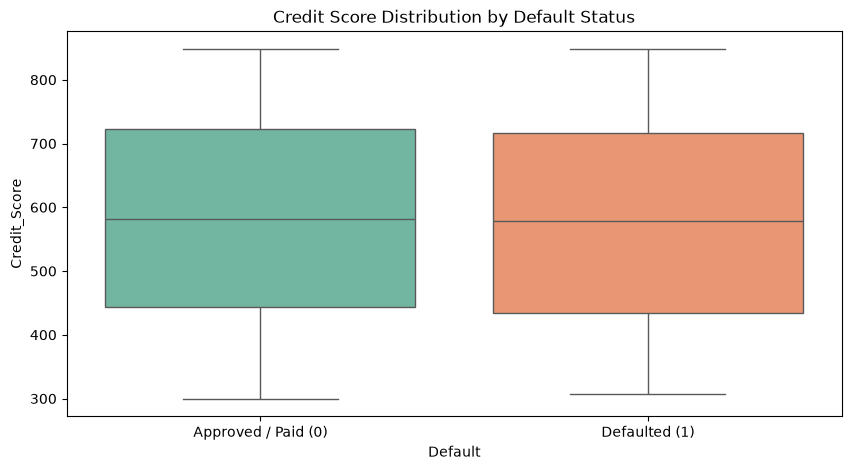

In [18]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=loan, x='Default', y='Credit_Score', palette='Set2')
plt.title('Credit Score Distribution by Default Status')
plt.xticks([0, 1], ['Approved / Paid (0)', 'Defaulted (1)'])
plt.show()

In [19]:
# Look at default rates across housing status
print("Default Rate by Housing Status:")
print(loan.groupby('Housing_Status')['Default'].mean() * 100)

# Look at default rates across education levels
print("\nDefault Rate by Education Level:")
print(loan.groupby('Education_Level')['Default'].mean() * 100)

Default Rate by Housing Status:
Housing_Status
Mortgage    13.753582
Own         13.636364
Rent        14.018692
Name: Default, dtype: float64

Default Rate by Education Level:
Education_Level
Bachelors      13.306452
High School    11.715481
Masters        15.415020
PhD            14.615385
Name: Default, dtype: float64


In [20]:
# Look at default rates across housing status
print("Default Rate by Housing Status:")
print(loan.groupby('Housing_Status')['Default'].mean() * 100)

# Look at default rates across education levels
print("\nDefault Rate by Education Level:")
print(loan.groupby('Education_Level')['Default'].mean() * 100)

Default Rate by Housing Status:
Housing_Status
Mortgage    13.753582
Own         13.636364
Rent        14.018692
Name: Default, dtype: float64

Default Rate by Education Level:
Education_Level
Bachelors      13.306452
High School    11.715481
Masters        15.415020
PhD            14.615385
Name: Default, dtype: float64


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Separate features (X) and target (y)
X = loan_encoded.drop(columns=['Default'])
y = loan_encoded['Default']

# 2. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6)
model.fit(X_train, y_train)

# 4. Make predictions
y_pred = model.predict(X_test)

# 5. Evaluate how well it flags defaulters
print(f"Model Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=['Approve (0)', 'Reject/Risk (1)']))

Model Overall Accuracy: 86.00%

Confusion Matrix:
[[172   0]
 [ 28   0]]

Detailed Performance Report:
                 precision    recall  f1-score   support

    Approve (0)       0.86      1.00      0.92       172
Reject/Risk (1)       0.00      0.00      0.00        28

       accuracy                           0.86       200
      macro avg       0.43      0.50      0.46       200
   weighted avg       0.74      0.86      0.80       200



c:\Users\Yatish Agarwal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Yatish Agarwal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Yatish Agarwal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Separate features (X) and target (y)
X = loan_encoded.drop(columns=['Default'])
y = loan_encoded['Default']

# 2. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and train the Model with CLASS WEIGHTS BALANCED
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6, class_weight='balanced')
model.fit(X_train, y_train)

# 4. Make predictions
y_pred = model.predict(X_test)

# 5. Evaluate how well it flags defaulters now
print(f"Model Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=['Approve (0)', 'Reject/Risk (1)']))

Model Overall Accuracy: 72.50%

Confusion Matrix:
[[135  37]
 [ 18  10]]

Detailed Performance Report:
                 precision    recall  f1-score   support

    Approve (0)       0.88      0.78      0.83       172
Reject/Risk (1)       0.21      0.36      0.27        28

       accuracy                           0.72       200
      macro avg       0.55      0.57      0.55       200
   weighted avg       0.79      0.72      0.75       200



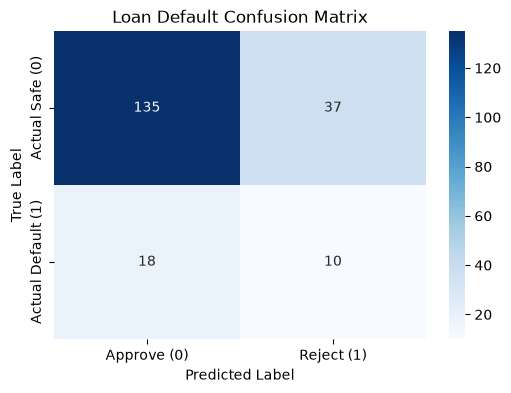

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Approve (0)', 'Reject (1)'],
            yticklabels=['Actual Safe (0)', 'Actual Default (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Loan Default Confusion Matrix')
plt.show()

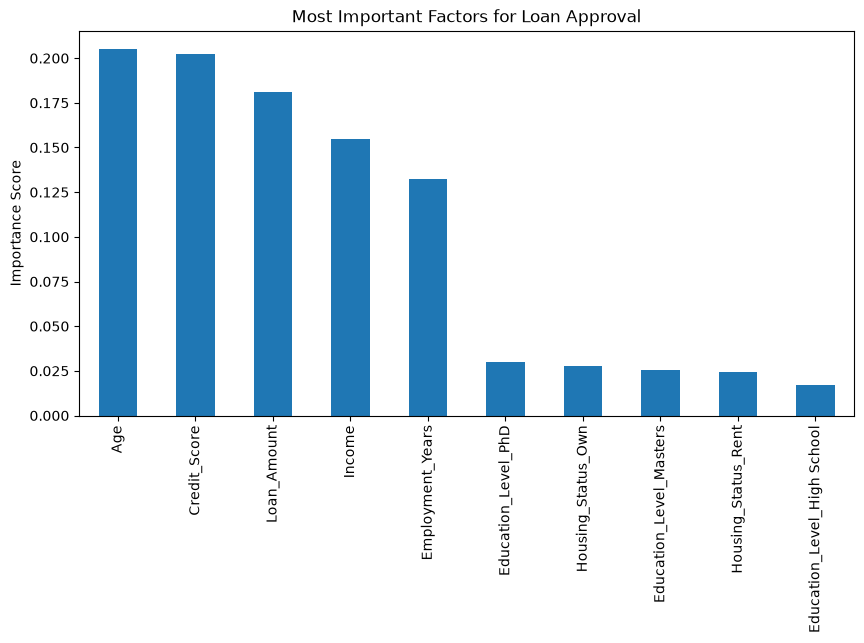

In [24]:
import pandas as pd

# Get feature importances
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5))
plt.title("Most Important Factors for Loan Approval")
plt.ylabel("Importance Score")
plt.show()